In [226]:
import json 
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [227]:
base_path = '/home/nddang/ai_projects/vexu_synthetic/renders/gpu_0/scene_20251101_000149'
with open(f"{base_path}/capture_meta.json", 'r') as f:
    metadata = json.load(f)
with open("v1_raster_metadata.json", 'r') as f:
    raster_metadata = json.load(f)

In [228]:
camera_idx = -1
E_matrix = np.array(metadata['cameras'][camera_idx]['extrinsic_matrix'])
flip = np.diag([1.0, -1.0, -1.0, 1.0])  # 4x4
E_matrix = flip @ E_matrix  # now world->camera in CV-like axes
print(f"Loaded E_matrix from camera {metadata['cameras'][camera_idx]['name']}:\n{E_matrix}")
sensor_h, sensor_w = 3.6 / 1000, 5.76 / 1000  # sensor size in meters
f = 1.47/1000  # focal length in meters
H, W = 704, 1280  # image size in pixels
cy, cx = H / 2, W / 2  # principal point in pixels
fy, fx = f * H / sensor_h, f * W / sensor_w  # focal lengths in pixels
K_matrix = np.array([[fx, 0, cx],
                     [0, fy, cy],
                     [0, 0, 1]])
P = K_matrix @ E_matrix[:3, :4]

Loaded E_matrix from camera CamRight:
[[-4.29384202e-01  9.03121710e-01  1.77635642e-15 -3.47576946e-01]
 [-3.94767063e-08 -1.87689793e-08 -1.00000000e+00  4.79290523e-02]
 [-9.03121710e-01 -4.29384202e-01  4.37113812e-08  1.06997502e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


In [229]:
query_point = np.array([
                -0.08831177651882172,
                0.08832187950611115,
                -0.20720089972019196
            ] + [1.0])  # homogeneous coordinates
projected_point = P @ query_point
print(f"Depth of the projected point: {projected_point[2]}")
u, v = int(projected_point[0]/projected_point[2]), int(projected_point[1]/projected_point[2])
u, v

Depth of the projected point: 1.1118072723213615


(572, 417)

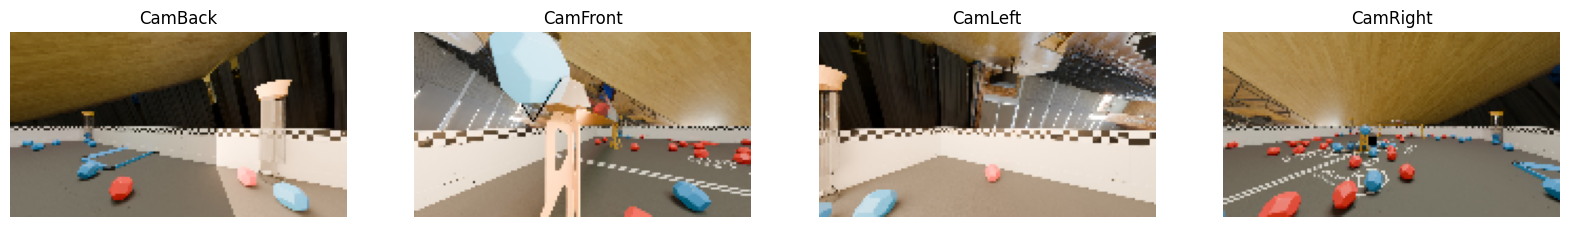

In [230]:
# load images from jpeg format
camback = Image.open(f'{base_path}/CamBack.jpg')
camfront = Image.open(f'{base_path}/CamFront.jpg')
camleft = Image.open(f'{base_path}/CamLeft.jpg')
camright = Image.open(f'{base_path}/CamRight.jpg')
camback = np.array(camback)
camfront = np.array(camfront)
camleft = np.array(camleft)
camright = np.array(camright)   
# downsample image by 4
downsample = 8
camback = camback[::downsample, ::downsample, :]
camfront = camfront[::downsample, ::downsample, :]
camleft = camleft[::downsample, ::downsample, :]
camright = camright[::downsample, ::downsample, :]
for i in range(-2, 2):
    for j in range(-2, 2):
        camright[v//downsample + i, u//downsample + j, :] = [0, 0, 0]
        
        

fig, axs = plt.subplots(1,4, figsize=(20,5))
axs[0].imshow(camback)
axs[0].set_title('CamBack')
axs[0].axis('off')
axs[1].imshow(camfront)
axs[1].set_title('CamFront')
axs[1].axis('off')
axs[2].imshow(camleft)
axs[2].set_title('CamLeft')
axs[2].axis('off')
axs[3].imshow(camright)
axs[3].set_title('CamRight')
axs[3].axis('off')
plt.show()

In [231]:
def compute_raster_indices(meta_path: str, N: int = 64):
    """Compute raster indices based on Blender's field metadata.
    
    Args:
        meta_path (str): Path to the metadata JSON file.
        N (int): Size of the raster grid (N x N).
    """
    with open(meta_path, 'r') as f:
        meta = json.load(f)

    ground = meta['Ground']
    min_x, max_x = ground['min_x'], ground['max_x']
    min_y, max_y = ground['min_y'], ground['max_y']

    def world_to_raster(x, y):
        ix = int((x - min_x) / (max_x - min_x) * (N - 1))
        iy = int((y - min_y) / (max_y - min_y) * (N - 1))
        return ix, iy

    raster_indices = {"Ground": [], "LongGoal": {}, "Loader": {}, "CenterGoal": {}}
    raster_indices["Ground"] = [i for i in range(N * N)]

    for lg_name, lg in meta.get('LongGoal', {}).items():
        min_y_idx = world_to_raster(lg['x'], lg['min_y'])[1]
        max_y_idx = world_to_raster(lg['x'], lg['max_y'])[1]
        x_idx, _ = world_to_raster(lg['x'], (lg['min_y'] + lg['max_y']) / 2)
        indices = [x_idx* N + iy for iy in range(min_y_idx, max_y_idx + 1)]
        raster_indices["LongGoal"][lg_name] = sorted(indices)

    for ld_name, ld in meta.get('Loader', {}).items():
        x_idx, y_idx = world_to_raster(ld['x'], ld['y'])
        raster_indices["Loader"][ld_name] = [x_idx * N + y_idx]

    for cg_name, cg in meta.get('CenterGoal', {}).items():
        local = cg['local_pose']
        world_matrix = np.array(cg['world_matrix'])
        xs = np.linspace(local['min_x'], local['max_x'], N)
        ys = np.linspace(local['min_y'], local['max_y'], N)
        indices = []
        for x in xs:
            for y in ys:
                local_pt = np.array([x, y, 0, 1])
                world_pt = world_matrix @ local_pt
                ix, iy = world_to_raster(world_pt[0], world_pt[1])
                indices.append(ix * N + iy)
        raster_indices["CenterGoal"][cg_name] = sorted(set(indices))
    return raster_indices, {'min_x': min_x, 'max_x': max_x, 'min_y': min_y, 'max_y': max_y}

In [232]:
compute_raster_indices("v1_raster_metadata.json", N=48)

({'Ground': [0,
   1,
   2,
   3,
   4,
   5,
   6,
   7,
   8,
   9,
   10,
   11,
   12,
   13,
   14,
   15,
   16,
   17,
   18,
   19,
   20,
   21,
   22,
   23,
   24,
   25,
   26,
   27,
   28,
   29,
   30,
   31,
   32,
   33,
   34,
   35,
   36,
   37,
   38,
   39,
   40,
   41,
   42,
   43,
   44,
   45,
   46,
   47,
   48,
   49,
   50,
   51,
   52,
   53,
   54,
   55,
   56,
   57,
   58,
   59,
   60,
   61,
   62,
   63,
   64,
   65,
   66,
   67,
   68,
   69,
   70,
   71,
   72,
   73,
   74,
   75,
   76,
   77,
   78,
   79,
   80,
   81,
   82,
   83,
   84,
   85,
   86,
   87,
   88,
   89,
   90,
   91,
   92,
   93,
   94,
   95,
   96,
   97,
   98,
   99,
   100,
   101,
   102,
   103,
   104,
   105,
   106,
   107,
   108,
   109,
   110,
   111,
   112,
   113,
   114,
   115,
   116,
   117,
   118,
   119,
   120,
   121,
   122,
   123,
   124,
   125,
   126,
   127,
   128,
   129,
   130,
   131,
   132,
   133,
   134,
   135,
   136,
   1